In [4]:
!pip install gym yfinance ta

# Libraries

In [12]:
import gym
import yfinance as yf
import ta  
from tqdm import tqdm
import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("darkgrid")

### Loading Data

In [14]:
tickers = "TSLA"
dt = yf.download(tickers = tickers ,
                  period = "2y",        
                  interval = "1h",      
                  ignore_tz = True,      
                  prepost = False)       
print("shape of dataset: ",dt.shape)
dt.head()

[*********************100%***********************]  1 of 1 completed

shape of dataset:  (3495, 5)


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Datetime,,,,,
2023-09-12 14:30:00,268.088501,268.420013,266.760010,267.980011,0
2023-09-12 15:30:00,267.390015,268.140015,266.890015,268.100006,7638543
2023-09-13 09:30:00,270.569885,274.980011,268.100006,270.070007,40560087
2023-09-13 10:30:00,272.389893,273.190002,270.119995,270.570007,17387611
2023-09-13 11:30:00,271.179993,273.079987,270.000000,272.364990,12369899


In [15]:
split_line = int(np.round(len(dt)* 0.1))

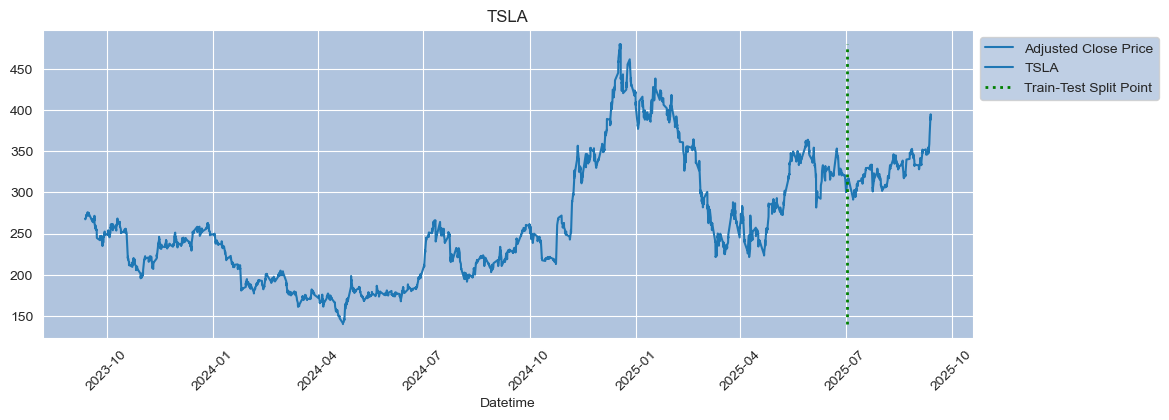

In [18]:
# Get min and max of 'Close'
adj_close_min = dt['Close'].min()
adj_close_max = dt['Close'].max()

# Set the background color
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))

# Create line plot
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
plt.xticks(rotation=45)
plt.title(tickers)

# single vline with full ymin and ymax
plt.vlines(x=dt.index[-split_line], ymin=adj_close_min, ymax=adj_close_max, colors='green', ls=':', lw=2, label='Train-Test Split Point')

plt.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.show()

# Data Preparation 

### 1.Trend Indicator (Exponential Moving Average)

In [22]:
print(type(dt[['Close']]))

<class 'pandas.core.frame.DataFrame'>


In [24]:
cl = dt[['Close']].squeeze() # convertion  of dataframe to series

In [26]:
dt['EMA7'] = ta.trend.EMAIndicator(close= cl, window= 7, fillna= False).ema_indicator()
dt['EMA14'] = ta.trend.EMAIndicator(close= cl, window= 14, fillna= False).ema_indicator()
dt['EMA50'] = ta.trend.EMAIndicator(close=cl, window= 50, fillna= False).ema_indicator()
dt['EMA200'] = ta.trend.EMAIndicator(close= cl, window= 50, fillna= False).ema_indicator()

Text(0.5, 1.0, 'TSLA')

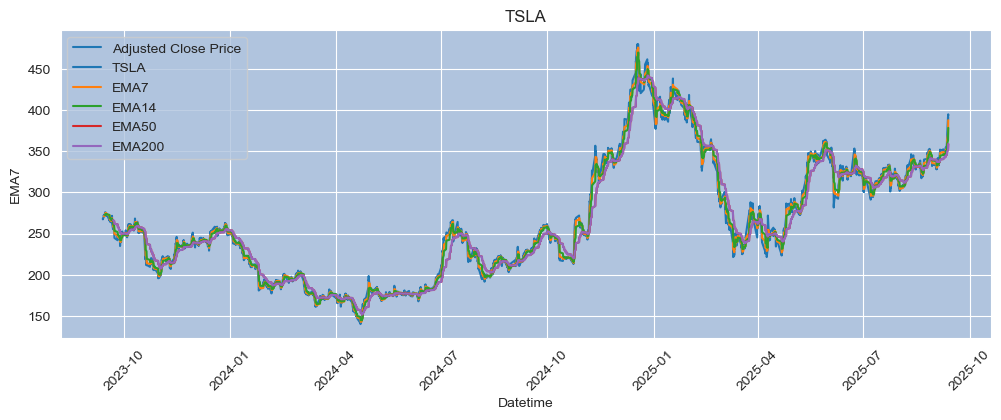

In [28]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["EMA7"],label = "EMA7")
sns.lineplot(data=dt["EMA14"],label = "EMA14")
sns.lineplot(data=dt["EMA50"],label = "EMA50")
sns.lineplot(data=dt["EMA200"],label = "EMA200")


plt.xticks(rotation=45)
plt.title(tickers)

### 2.Momentum Indicator (Relative Strength Index & Moving Average Convergence Divergence)

In [30]:
dt['MACD_line'] =ta.trend.MACD(close= cl, window_slow= 26, window_fast= 12, window_sign = 9, fillna = False).macd()
dt['MACD_signal'] =ta.trend.MACD(close= cl, window_slow= 26, window_fast= 12, window_sign = 9, fillna = False).macd_signal()
dt['MACD_diff'] =ta.trend.MACD(close= cl, window_slow= 26, window_fast= 12, window_sign = 9, fillna = False).macd_diff()

Text(0.5, 1.0, 'TSLA')

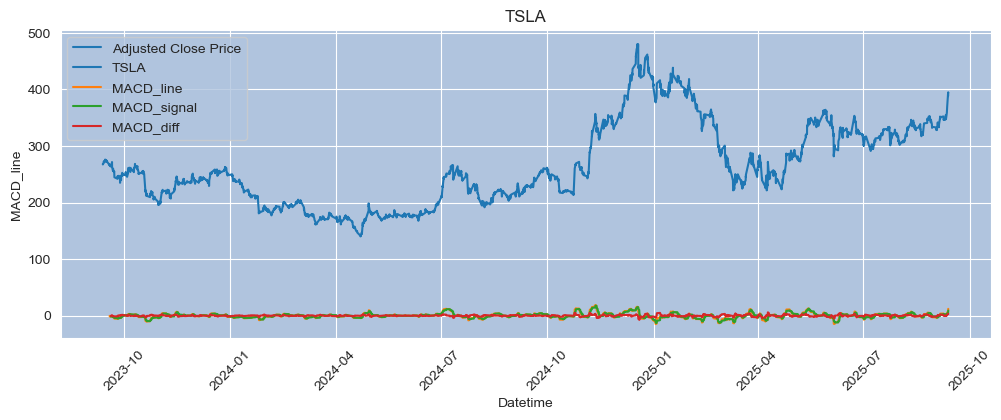

In [31]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["MACD_line"],label = "MACD_line")
sns.lineplot(data=dt["MACD_signal"],label = "MACD_signal")
sns.lineplot(data=dt["MACD_diff"],label = "MACD_diff")

plt.xticks(rotation=45)
plt.title(tickers)

In [34]:
dt['RSI']=ta.momentum.RSIIndicator(close= cl, window= 14, fillna= False).rsi()

Text(0.5, 1.0, 'TSLA')

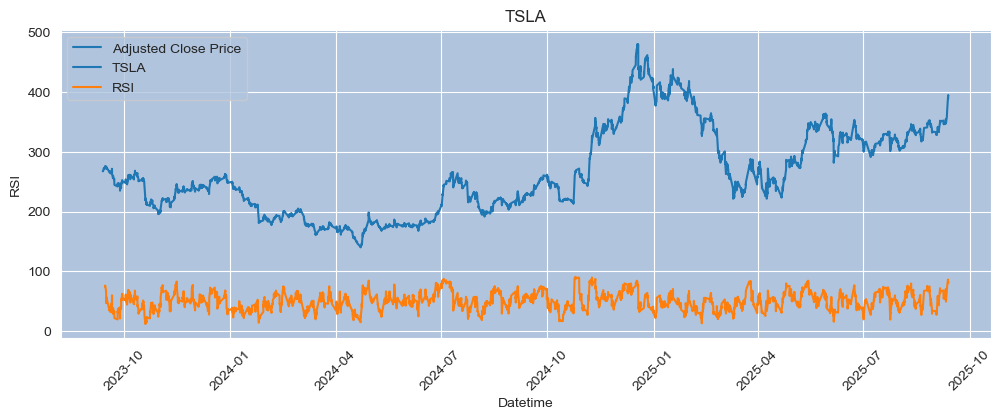

In [35]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["RSI"],label = "RSI")
plt.xticks(rotation=45)
plt.title(tickers)

### 3.Volume Indicator (On Balance Volume)

In [39]:
vl = dt[['Volume']].squeeze()
dt['OBV']= ta.volume.OnBalanceVolumeIndicator(close=cl, volume= vl, fillna = False).on_balance_volume()
dt.head()

Price,Close,High,Low,Open,Volume,EMA7,EMA14,EMA50,EMA200,MACD_line,MACD_signal,MACD_diff,RSI,OBV
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,,,,,
Datetime,,,,,,,,,,,,,,
2023-09-12 14:30:00,268.088501,268.420013,266.760010,267.980011,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2023-09-12 15:30:00,267.390015,268.140015,266.890015,268.100006,7638543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7638543
2023-09-13 09:30:00,270.569885,274.980011,268.100006,270.070007,40560087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32921544
2023-09-13 10:30:00,272.389893,273.190002,270.119995,270.570007,17387611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50309155
2023-09-13 11:30:00,271.179993,273.079987,270.000000,272.364990,12369899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37939256


Text(0.5, 1.0, 'TSLA')

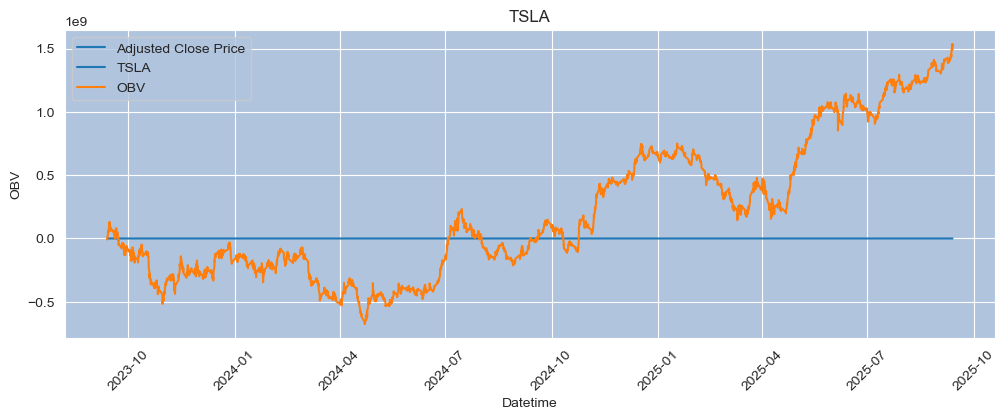

In [41]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["OBV"],label = "OBV")
plt.xticks(rotation=45)
plt.title(tickers)

### 4.Volatile Indicator (Bollinger Bands)

In [44]:
dt['BBH']=ta.volatility.BollingerBands(cl, window = 20, window_dev = 2, fillna = False).bollinger_hband_indicator()
dt['BBL']=ta.volatility.BollingerBands(cl, window = 20, window_dev = 2, fillna = False).bollinger_lband_indicator()
dt.head()

Price,Close,High,Low,Open,Volume,EMA7,EMA14,EMA50,EMA200,MACD_line,MACD_signal,MACD_diff,RSI,OBV,BBH,BBL
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,
2023-09-12 14:30:00,268.088501,268.420013,266.760010,267.980011,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0
2023-09-12 15:30:00,267.390015,268.140015,266.890015,268.100006,7638543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7638543,0.0,0.0
2023-09-13 09:30:00,270.569885,274.980011,268.100006,270.070007,40560087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32921544,0.0,0.0
2023-09-13 10:30:00,272.389893,273.190002,270.119995,270.570007,17387611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50309155,0.0,0.0
2023-09-13 11:30:00,271.179993,273.079987,270.000000,272.364990,12369899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37939256,0.0,0.0


Text(0.5, 1.0, 'TSLA')

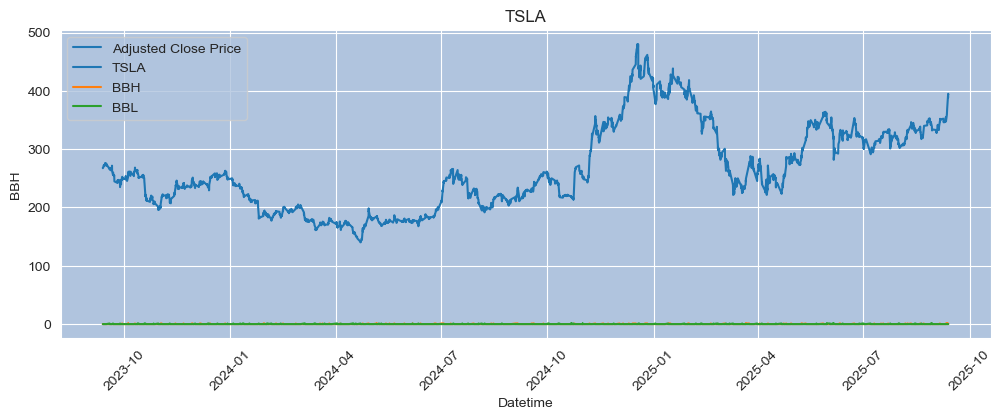

In [46]:
sns.set_style(rc = {'axes.facecolor': 'lightsteelblue'})
plt.figure(figsize=(12,4))
sns.lineplot(data=dt["Close"],label = "Adjusted Close Price")
sns.lineplot(data=dt["BBH"],label = "BBH")
sns.lineplot(data=dt["BBL"],label = "BBL")
plt.xticks(rotation=45)
plt.title(tickers)

In [48]:
dt.columns

MultiIndex([(      'Close', 'TSLA'),
            (       'High', 'TSLA'),
            (        'Low', 'TSLA'),
            (       'Open', 'TSLA'),
            (     'Volume', 'TSLA'),
            (       'EMA7',     ''),
            (      'EMA14',     ''),
            (      'EMA50',     ''),
            (     'EMA200',     ''),
            (  'MACD_line',     ''),
            ('MACD_signal',     ''),
            (  'MACD_diff',     ''),
            (        'RSI',     ''),
            (        'OBV',     ''),
            (        'BBH',     ''),
            (        'BBL',     '')],
           names=['Price', 'Ticker'])

In [49]:
train_data = dt.iloc[:-split_line,:]
test_data = dt.iloc[-split_line:,:]
input_shape= train_data.shape[1]
print(input_shape)
print('Training data:',train_data.shape)
print('Testing data',test_data.shape)

16
Training data: (3145, 16)
Testing data (350, 16)


# Environment

### Setting up the action space and observation space

In [54]:
import gym
import numpy as np

class StockTradingEnv(gym.Env):
    def __init__(self, data, initial_cash=10000, commission=0.000):
        self.action_space = gym.spaces.MultiDiscrete([3, 10])  # [action, number of shares]
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.data = data
        self.initial_cash = initial_cash
        self.commission = commission
        self.end_step = len(self.data) - 1

        self.reset()

    def reset(self):
        self.current_step = 0
        self.profits = 0
        self.shares_held = 0
        self.cash = self.initial_cash
        self.buy_price = 0
        self.sell_price = 0
        self.done = False
        return self._get_obs()

    def step(self, action):
        action_type, amount = action

        if action_type == 0: # Buy
            # Add .item() here to convert the result to a single number
            cost = (self.data['Close'].iloc[self.current_step] * amount).item()
            
            if self.cash >= cost:
                self.cash -= cost
                self.shares_held += amount
                self.buy_price = self.data['Close'].iloc[self.current_step]
        
        elif action_type == 1: # Sell
            shares_sold = min(self.shares_held, amount)
            # Add .item() here as well for consistency
            revenue = (self.data['Close'].iloc[self.current_step] * shares_sold).item()
            
            self.cash += revenue
            self.profits += (self.data['Close'].iloc[self.current_step] - self.buy_price) * shares_sold
            self.shares_held -= shares_sold
            self.sell_price = self.data['Close'].iloc[self.current_step]

        self.current_step += 1
        
        portfolio_value = self.cash + (self.shares_held * self.data['Close'].iloc[self.current_step])
        reward = portfolio_value - (self.cash + (self.shares_held * self.data['Close'].iloc[self.current_step - 1]))
        
        done = (self.current_step == self.end_step)
        return self._get_obs(), reward, done, {}

    def _get_obs(self):
        obs = np.array([
            float(self.data['Close'].iloc[self.current_step]),
            float(self.data['EMA7'].iloc[self.current_step]),
            float(self.data['EMA14'].iloc[self.current_step]),
            float(self.data['EMA50'].iloc[self.current_step]),
            float(self.data['EMA200'].iloc[self.current_step]),
            float(self.data['MACD_line'].iloc[self.current_step]),
            float(self.data['MACD_signal'].iloc[self.current_step]),
            float(self.data['MACD_diff'].iloc[self.current_step]),
            float(self.data['RSI'].iloc[self.current_step]),
            float(self.data['OBV'].iloc[self.current_step]),
            float(self.data['BBH'].iloc[self.current_step]),
            float(self.data['BBL'].iloc[self.current_step]),
        ])
        return obs

# Defining the Agent


In [57]:
import random
import numpy as np
from collections import deque
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

class DQNAgent:
    def __init__(self, state_size, action_space,memory_size=3000):
        # Initialize instance variables
        self.state_size = state_size
        self.action_space = action_space
        self.action_size = action_space.nvec.prod()
        self.memory = deque(maxlen=memory_size)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.01
        self.model = self._build_model()

    def _build_model(self):
        # Build the neural network model
        model = Sequential()
        model.add(Dense(64, input_dim=self.state_size))
        model.add(Dense(128, activation='relu'))
        model.add(Dense(256, activation='relu'))
        model.add(Dense(128, activation='relu'))
        model.add(Dense(self.action_size, activation='relu'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def remember(self, state, action, reward, next_state, done):
        # Store the experience in memory
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        # Choose an action using the epsilon-greedy strategy
        if np.random.rand() <= self.epsilon:
            return (random.randrange(self.action_space.nvec[0]), random.randrange(self.action_space.nvec[1]))
        act_values = self.model.predict(state)
        return np.unravel_index(np.argmax(act_values[0]), self.action_space.nvec)

    def replay(self, batch_size):
        # Train the model using random samples from memory
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                # Update target value for non-terminal states
                target = reward + self.gamma * np.amax(self.model.predict(next_state)[0])
            target_f = self.model.predict(state)

            # Convert the action tuple to a linear index
            action_idx = np.ravel_multi_index(action, self.action_space.nvec)

            # Update the target value for the chosen action
            target_f[0][action_idx] = target
            self.model.fit(state, target_f, epochs=1, verbose=0)

        # Decay the exploration rate if it's above the minimum threshold
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# Training the Agent

In [59]:
# Load the stock data
data = train_data

# Create the environment
env = StockTradingEnv(data)
state_size = env.observation_space.shape[0]
action_size = env.action_space.nvec.prod()

# Create and train the agent
agent = DQNAgent(state_size, env.action_space)
episodes = 50
batch_size = 32

for e in tqdm(range(episodes)):
    state = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0

    while True:
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        total_reward += reward
        next_state = np.reshape(next_state, [1, state_size])

        agent.remember(state, action, reward, next_state, done)
        state = next_state

        if done:
            print(f'Episode: {e + 1}/{episodes}, Total Reward: {total_reward}, Epsilon: {agent.epsilon:.2}')
            break

    if len(agent.memory) > batch_size:
        agent.replay(batch_size)


  0%|                                                                                           | 0/50 [00:00<?, ?it/s]

Episode: 1/50, Total Reward: Ticker
TSLA   -298.539871
dtype: float64, Epsilon: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1

  2%|█▋                                                                                 | 1/50 [01:05<53:43, 65.78s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Episode: 2/50, Total Reward: Ticker
TSLA    1772.436874
dtype: float64, Epsilon: 0.99
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/

  4%|███▎                                                                               | 2/50 [02:15<54:26, 68.06s/it]

...

 96%|███████████████████████████████████████████████████████████████████████████▊   | 48/50 [1:24:59<03:59, 119.88s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━

 98%|█████████████████████████████████████████████████████████████████████████████▍ | 49/50 [1:27:04<02:01, 121.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [1:29:23<00:00, 107.27s/it]


# Testing the Agent

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

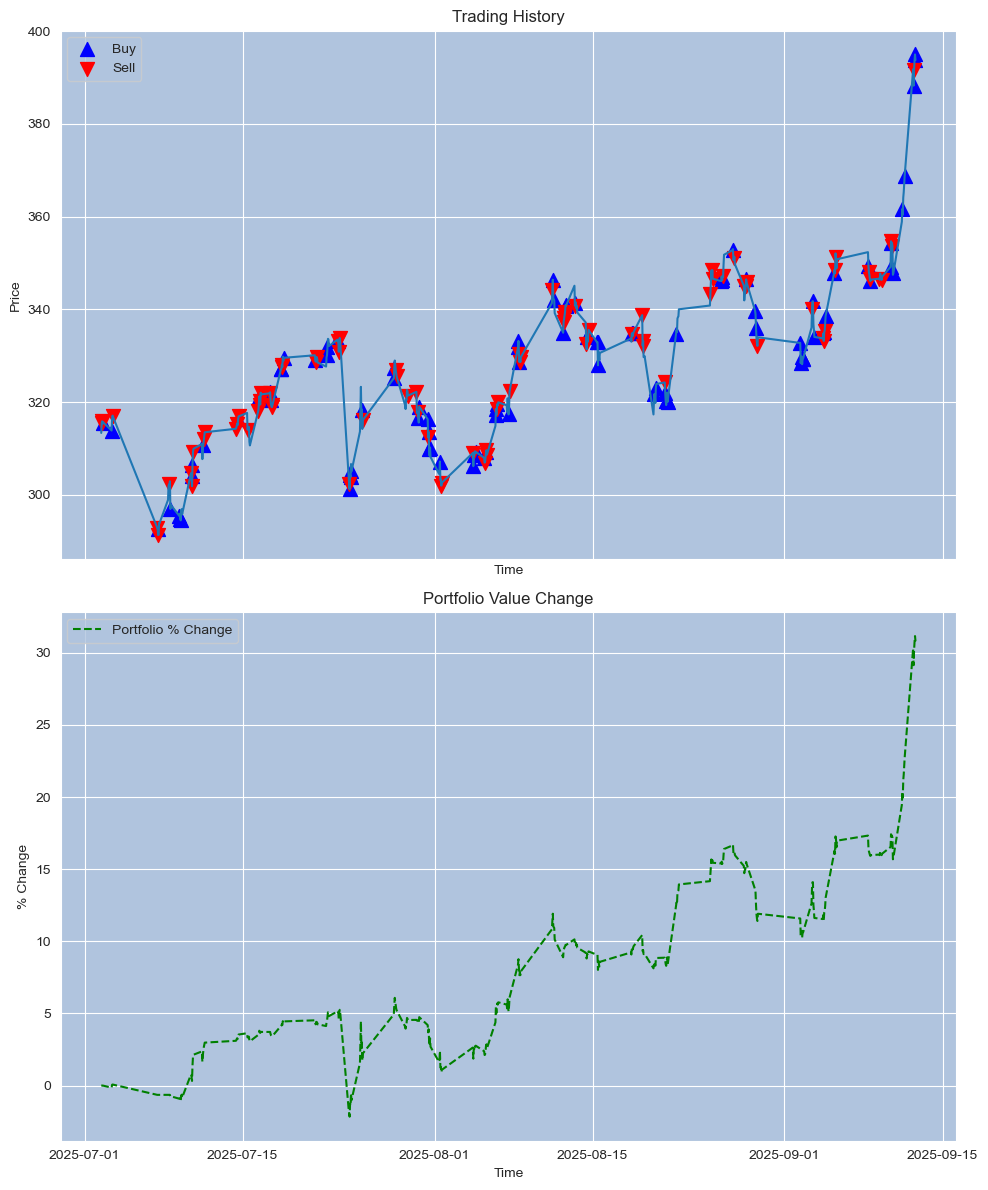

In [72]:
import matplotlib.pyplot as plt
import numpy as np
test_data = test_data.iloc[:,:] 
verbose = 0

# Create the test environment
test_env = StockTradingEnv(test_data, initial_cash=10000)

# Test the agent
state = test_env.reset()
state = np.reshape(state, [1, state_size])
total_reward = 0

# Initialize lists to store the buy and sell prices and the corresponding time steps
buy_prices = []
buy_times = []
sell_prices = []
sell_times = []

# Initialize the list to store portfolio values and add the initial portfolio value
portfolio_values = [test_env.cash]

while True:
    action = agent.act(state)
    next_state, reward, done, _ = test_env.step(action)

    # Calculate the total portfolio value
    portfolio_value = (test_env.cash + (test_env.shares_held * test_env.data['Close'].iloc[test_env.current_step])).item()
    portfolio_values.append(portfolio_value)

    # Print the action details
    action_type, shares = action
    if(verbose == 1):
        if action_type == 0:
            print(f"Buy {shares} shares at price {test_env.data['Close'].iloc[test_env.current_step]}")
        elif action_type == 1:
            print(f"Sell {shares} shares at price {test_env.data['Close'].iloc[test_env.current_step]}")

        print(f"Available cash: {test_env.cash}",f",Shares held: {test_env.shares_held}",f",Reward: {reward}")
        print("------------------------------------------------")

    total_reward += reward
    next_state = np.reshape(next_state, [1, state_size])
    state = next_state
    
    # Check if a buy action was taken and record the price and time step (CORRECTED)
    if action[0] == 0:
        buy_prices.append(test_data['Close'].iloc[test_env.current_step])
        buy_times.append(test_data.index[test_env.current_step])

    # Check if a sell action was taken and record the price and time step (CORRECTED)
    elif action[0] == 1:
        sell_prices.append(test_data['Close'].iloc[test_env.current_step])
        sell_times.append(test_data.index[test_env.current_step])

    if done:
        print(f'Test: Total Reward: {total_reward}')
        break

# Calculate the percentage change in the portfolio value
portfolio_percentage_changes = [((value - portfolio_values[0]) / portfolio_values[0]) * 100 for value in portfolio_values]

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot the historical price data as a line chart on the first subplot
ax1.plot(test_data.index, test_data['Close'])

# Plot the buy and sell actions as blue and red dots, respectively, on the first subplot
ax1.scatter(buy_times, buy_prices, color='b', marker='^', label='Buy', s=100)
ax1.scatter(sell_times, sell_prices, color='r', marker='v', label='Sell', s=100)
ax1.set_title('Trading History')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.legend()

# Plot the percentage change in the portfolio value on the second subplot
ax2.plot(test_data.index, portfolio_percentage_changes[:len(test_data.index)], color='g', linestyle='--', label='Portfolio % Change')
ax2.set_title('Portfolio Value Change')
ax2.set_xlabel('Time')
ax2.set_ylabel('% Change')
ax2.legend()

# Display the chart
plt.tight_layout()
plt.show()